# **YOLO Instance Segmentation**

# 1.환경준비

## (1) 라이브러리 설치

In [ ]:
!pip install ultralytics -q

## (2) 라이브러리 불러오기

In [1]:
from ultralytics import settings, YOLO
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import Video
import numpy as np

## (3) YOLO 설정

* 파일 경로 설정

In [2]:
# 현재 세팅을 확인해 봅시다.
settings

{'settings_version': '0.0.6',
 'datasets_dir': './',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': 'e93724c3a62b829fe2022931d0c4e07c6e9e5bbc21bb08e52bb2b401c0a189fa',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

In [3]:
# 콜랩 파일 탭에 보이는 경로('/content/')로 변경해 봅시다.
settings['datasets_dir'] = './'
settings.update()
settings

{'settings_version': '0.0.6',
 'datasets_dir': './',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': 'e93724c3a62b829fe2022931d0c4e07c6e9e5bbc21bb08e52bb2b401c0a189fa',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

# 2.모델 사용

## (1) 모델 다운로드

- 모델의 구조와 해당 구조에 맞게 사전 학습된 가중치를 불러온다.
- Parameters
    * model : 모델 구조 또는 모델 구조 + 가중치 설정. task와 맞는 모델을 선택해야 한다.
    * task : detect, segment, classify, pose 중 택일

In [4]:
model = YOLO(model='yolo11s-seg.pt')

## (2) 모델 사용 : 이미지

![](https://file.fgtv.com/nanum_files/USERUPLOAD/N2_511/151021160645_01.jpg)

In [5]:
image_path = 'https://file.fgtv.com/nanum_files/USERUPLOAD/N2_511/151021160645_01.jpg'
results = model.predict(image_path, save=True)
results[0].show()  # 탐지된 객체 출력


image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\151021160645_01.jpg: 448x640 3 persons, 94.7ms
Speed: 2.9ms preprocess, 94.7ms inference, 9.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\runs\segment\predict


In [6]:
r = results[0]
print(type(r.masks), None if r.masks is None else r.masks.data.shape)
# 예: (N, H, W) 형태면 N개의 개별 인스턴스 마스크가 나온 것
# 개수 확인
print("num instances:", 0 if r.masks is None else r.masks.data.shape[0])

<class 'ultralytics.engine.results.Masks'> torch.Size([3, 448, 640])
num instances: 3


## (3) 세그멘테이션 결과 열어보기

In [7]:
print(type(results))
print(len(results))

<class 'list'>
1


In [8]:
type(results[0])

ultralytics.engine.results.Results

In [9]:
r.boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0.], device='cuda:0')
conf: tensor([0.8933, 0.8848, 0.8382], device='cuda:0')
data: tensor([[2.7494e+01, 9.2755e+01, 4.4358e+02, 6.5897e+02, 8.9332e-01, 0.0000e+00],
        [5.4245e+02, 1.0044e+00, 9.9885e+02, 6.5563e+02, 8.8477e-01, 0.0000e+00],
        [3.6954e+02, 9.1334e+01, 7.4030e+02, 6.5826e+02, 8.3816e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (666, 1000)
shape: torch.Size([3, 6])
xywh: tensor([[235.5368, 375.8620, 416.0865, 566.2131],
        [770.6506, 328.3175, 456.4005, 654.6263],
        [554.9191, 374.7985, 370.7659, 566.9293]], device='cuda:0')
xywhn: tensor([[0.2355, 0.5644, 0.4161, 0.8502],
        [0.7707, 0.4930, 0.4564, 0.9829],
        [0.5549, 0.5628, 0.3708, 0.8512]], device='cuda:0')
xyxy: tensor([[ 27.4936,  92.7555, 443.5800, 658.9686],
        [542.4503,   1.0044, 998.8508, 655.6307],
        [369.5361,  91.3338, 740.3020, 658.2631]], device='cuda:0')

In [10]:
for box in r.boxes:
    x_min, y_min, x_max, y_max = box.xyxy[0]  # 좌표
    conf = box.conf[0]
    cn = r.names[int(box.cls[0])]  # 클래스 이름
    print(f"좌표: {x_min}, {y_min}, {x_max}, {y_max} | conf. : {conf} | class : {cn}")

좌표: 27.493572235107422, 92.75546264648438, 443.58001708984375, 658.9685668945312 | conf. : 0.8933222889900208 | class : person
좌표: 542.4503173828125, 1.0044097900390625, 998.850830078125, 655.6306762695312 | conf. : 0.8847720623016357 | class : person
좌표: 369.5361022949219, 91.33381652832031, 740.302001953125, 658.2631225585938 | conf. : 0.8381595015525818 | class : person


* masks
    * 객체별 마스크 정보 (픽셀 단위)를 담고 있는 객체

In [11]:
results[0].masks

ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:0', dtype=torch.uint8)
orig_shape: (666, 1000)
shape: torch.Size([3, 448, 640])
xy: [array([[     229.69,      92.375],
       [     229.69,      98.625],
       [     226.56,      101.75],
       [     226.56,      103.31],
       [     223.44,

| 속성 | 설명 |
|----|----|
|masks.data | (num_instances, H, W) 형태의 마스크 텐서 (0~1 값)|
|masks.xy | 각 인스턴스의 마스크 외곽선을 polygon으로 표현한 좌표 리스트|
|masks.shape | 마스크 텐서의 크기 (인스턴스 개수, 높이, 너비)|
|masks.bool() | True/False 형태로 변환한 binary mask|


In [12]:
# 마스크 정보
masks = r.masks

print(masks.data.shape)  # 예: torch.Size([3, 448, 640]) → 3개의 인스턴스
print(masks.data[0])     # 첫 번째 객체의 마스크 (0~1 값의 텐서)

torch.Size([3, 448, 640])
tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], device='cuda:0', dtype=torch.uint8)


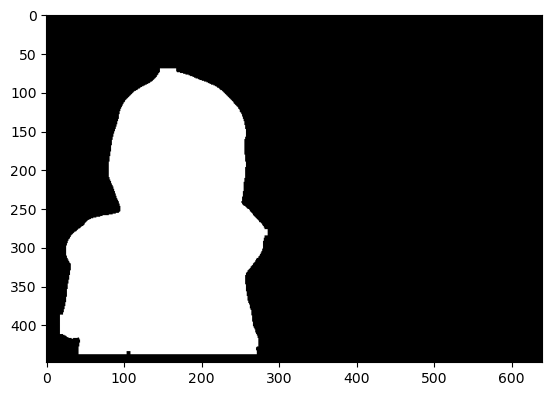

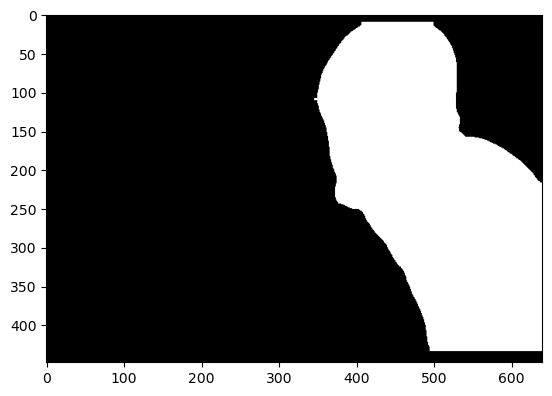

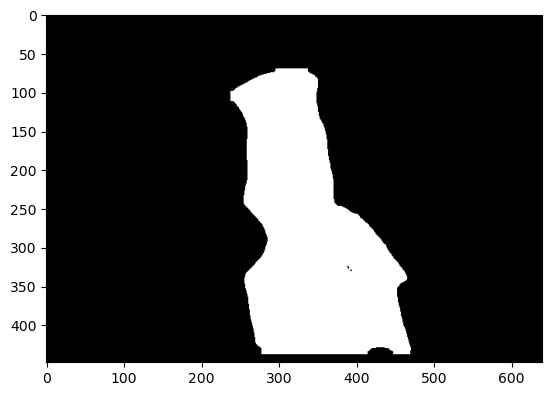

In [18]:
masks = r.masks

for i in range(3):
	mask = masks.data[i].to('cpu').numpy()
	plt.imshow(mask, cmap='gray')
	plt.show()

## (4) 실습
* 다양한 사진을 찾아서 세그멘테이션 해 봅시다.


image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\pexels-photo-139303.jpeg: 448x640 21 persons, 10 cars, 1 truck, 26.2ms
Speed: 2.5ms preprocess, 26.2ms inference, 2.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\runs\segment\predict


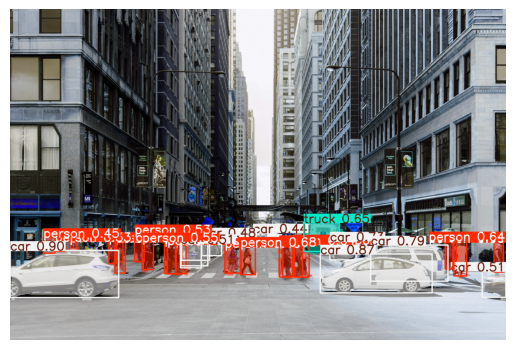

In [25]:
import matplotlib.pyplot as plt

# 예측 수행
results = model.predict(r".\data\pexels-photo-139303.jpeg", save=True)

# 첫 번째 결과의 이미지 시각화
plt.imshow(results[0].plot())  # 탐지 결과 그리기
plt.axis('off')                # 축 제거
plt.show()

## (5) 모델사용 : 동영상

* sample.mp4 파일을 업로드 합니다.

In [ ]:
# colab 파일 업로드
from google.colab import files
uploaded = files.upload()

* 동영상  실행

In [22]:
# 동영상  실행 및 결과 저장
results = model.predict(".\data\sample.mp4", save=True)  # 결과 자동 저장


WARNING 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/210) c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\sample.mp4: 416x640 2 cats, 1 dog, 1729.2ms
video 1/1 (frame 2/210) c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\sample.mp4: 416x640 2 cats, 1 dog, 20.7ms
video 1/1 (frame 3/210) c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\sample.mp4: 416x640 1 cat, 1 dog, 18.7ms
video 1/1 (frame 4/210) c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\data\

* 콜랩에서 영상 play를 위한 세팅

In [ ]:
# 영상 코덱 설치
!apt-get install -y ffmpeg

In [ ]:
# AVI to MP4로 변환 (YOLO 탐지 결과 파일명에 맞게 수정)
input_video_path = "runs/segment/predict/sample.avi"  # YOLO 탐지 결과 파일명
output_video_path = "runs/segment/predict/video_converted.mp4"

# FFmpeg를 사용하여 변환 (코덱: libx264)
!ffmpeg -i {input_video_path} -vcodec libx264 {output_video_path}

* 영상 paly

In [24]:
# YOLO 탐지 결과 동영상 재생
Video("runs/segment/predict/video_converted.mp4", embed=True)